### Chialvo Neuron Model Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import odeint
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns

class ChialvoNeuronNetwork:
    """Chialvo neuron model with network coupling"""

    def __init__(self, num_neurons, a=0.89, b=0.6, c=0.28, k=0.05, x0=0.0, y0=0.0):
        self.num_neurons = num_neurons
        self.a = a  # Recovery rate
        self.b = b  # Adaptation strength
        self.c = c  # Offset
        self.k = k  # Coupling strength
        self.x0 = x0  # Initial membrane potential
        self.y0 = y0  # Initial recovery variable

    def chialvo_individual(self, state, t, I_ext=0.03):
        """Single Chialvo neuron dynamics"""
        x, y = state
        dxdt = x**2 - y + I_ext  # Membrane potential
        dydt = self.a * y - self.b * x + self.c  # Recovery variable
        return [dxdt, dydt]

    def chialvo_network(self, states, t, adjacency_matrix, I_ext=0.03):
        """Network-coupled Chialvo neurons"""
        derivatives = np.zeros_like(states)
        num_neurons = self.num_neurons

        for i in range(num_neurons):
            x_i, y_i = states[2*i], states[2*i + 1]

            # Individual dynamics
            dxdt_i = x_i**2 - y_i + I_ext
            dydt_i = self.a * y_i - self.b * x_i + self.c

            # Network coupling (diffusive coupling on membrane potential)
            coupling = 0
            for j in range(num_neurons):
                if adjacency_matrix[i, j] > 0:  # If neurons are connected
                    x_j = states[2*j]
                    coupling += self.k * adjacency_matrix[i, j] * (x_j - x_i)

            dxdt_i += coupling
            derivatives[2*i] = dxdt_i
            derivatives[2*i + 1] = dydt_i

        return derivatives

    def simulate_network(self, adjacency_matrix, t_span, initial_conditions=None):
        """Simulate the entire network"""
        if initial_conditions is None:
            # Random initial conditions near fixed point
            initial_conditions = np.random.normal(0, 0.1, 2 * self.num_neurons)

        solution = odeint(self.chialvo_network, initial_conditions, t_span,
                         args=(adjacency_matrix,))
        return solution

    def extract_membrane_potentials(self, solution):
        """Extract membrane potentials from solution"""
        return solution[:, 0::2]  # Every even index is x (membrane potential)

    def extract_recovery_variables(self, solution):
        """Extract recovery variables from solution"""
        return solution[:, 1::2]  # Every odd index is y (recovery variable)

def create_neuronal_network(num_neurons, connectivity='small_world', p_connect=0.1):
    """Create different types of neuronal networks"""
    if connectivity == 'small_world':
        G = nx.watts_strogatz_graph(num_neurons, k=6, p=p_connect)
    elif connectivity == 'scale_free':
        G = nx.barabasi_albert_graph(num_neurons, m=3)
    elif connectivity == 'random':
        G = nx.erdos_renyi_graph(num_neurons, p=p_connect)
    else:
        G = nx.connected_watts_strogatz_graph(num_neurons, k=6, p=p_connect)

    return nx.to_numpy_array(G)

def analyze_synchronization(membrane_potentials):
    """Analyze synchronization patterns in neuronal activity"""
    num_neurons = membrane_potentials.shape[1]
    sync_measures = {}

    # Phase synchronization (using Hilbert transform)
    from scipy.signal import hilbert
    analytic_signal = hilbert(membrane_potentials, axis=0)
    instantaneous_phase = np.angle(analytic_signal)

    # Order parameter for synchronization
    order_parameter = np.abs(np.mean(np.exp(1j * instantaneous_phase), axis=1))
    sync_measures['order_parameter'] = order_parameter

    # Pairwise phase coherence
    phase_coherence = np.zeros((num_neurons, num_neurons))
    for i in range(num_neurons):
        for j in range(i+1, num_neurons):
            phase_diff = np.exp(1j * (instantaneous_phase[:, i] - instantaneous_phase[:, j]))
            phase_coherence[i, j] = np.abs(np.mean(phase_diff))
            phase_coherence[j, i] = phase_coherence[i, j]

    sync_measures['phase_coherence'] = phase_coherence

    # Global synchronization error
    mean_potential = np.mean(membrane_potentials, axis=1)
    sync_error = np.std(membrane_potentials - mean_potential[:, np.newaxis], axis=1)
    sync_measures['sync_error'] = sync_error

    return sync_measures

### Chaotic Rewiring for Neuronal Networks

In [2]:
def chaotic_rewiring_neuronal(adjacency_matrix, time_steps, chaos_strength=0.1,
                             rewiring_prob=0.01, seed=42):
    """Apply chaotic rewiring to neuronal network adjacency matrix"""
    np.random.seed(seed)
    n_neurons = adjacency_matrix.shape[0]
    evolving_matrices = [adjacency_matrix.copy()]

    # Initialize chaotic maps for each possible connection
    chaotic_states = np.random.random((n_neurons, n_neurons))

    for t in range(time_steps):
        current_matrix = evolving_matrices[-1].copy()

        # Update chaotic states (logistic map)
        chaotic_states = chaos_strength * chaotic_states * (1 - chaotic_states)

        # Probabilistic rewiring based on chaotic states
        for i in range(n_neurons):
            for j in range(i+1, n_neurons):  # Undirected network
                if np.random.random() < rewiring_prob:
                    # Chaotic decision: rewire based on chaotic state
                    if chaotic_states[i, j] > 0.7 and current_matrix[i, j] == 0:
                        current_matrix[i, j] = 1
                        current_matrix[j, i] = 1
                    elif chaotic_states[i, j] < 0.3 and current_matrix[i, j] == 1:
                        current_matrix[i, j] = 0
                        current_matrix[j, i] = 0

        evolving_matrices.append(current_matrix)

    return evolving_matrices

def simulate_evolving_neuronal_network(num_neurons=50, simulation_time=1000,
                                      rewiring_steps=10, chaos_level=0.2):
    """Simulate neuronal network with chaotic rewiring"""
    # Create initial network
    adj_matrix = create_neuronal_network(num_neurons, 'small_world', 0.1)

    # Generate chaotic rewiring sequence
    evolving_adj_matrices = chaotic_rewiring_neuronal(
        adj_matrix, rewiring_steps, chaos_strength=chaos_level)

    # Initialize Chialvo network
    chialvo_net = ChialvoNeuronNetwork(num_neurons)

    # Simulate for each network configuration
    all_solutions = []
    sync_analyses = []

    t_span = np.linspace(0, 100, simulation_time)  # Time for each configuration

    for i, adj_matrix in enumerate(evolving_adj_matrices):
        print(f"Simulating network configuration {i+1}/{len(evolving_adj_matrices)}")

        # Continue from previous state or random initial condition
        if i == 0:
            initial_conditions = None
        else:
            # Continue from final state of previous simulation
            initial_conditions = all_solutions[-1][-1, :]

        solution = chialvo_net.simulate_network(adj_matrix, t_span, initial_conditions)
        all_solutions.append(solution)

        # Analyze synchronization
        membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
        sync_analysis = analyze_synchronization(membrane_potentials)
        sync_analyses.append(sync_analysis)

    return evolving_adj_matrices, all_solutions, sync_analyses, chialvo_net

##Neuronal Centrality Analysis

In [4]:
def neuronal_centrality_analysis(evolving_adj_matrices, all_solutions, chialvo_net):
    """Analyze centrality in evolving neuronal networks"""
    num_configurations = len(evolving_adj_matrices)
    num_neurons = evolving_adj_matrices[0].shape[0]

    centrality_metrics = {
        'firing_rate_centrality': np.zeros((num_configurations, num_neurons)),
        'phase_centrality': np.zeros((num_configurations, num_neurons)),
        'influence_centrality': np.zeros((num_configurations, num_neurons)),
        'sync_leadership': np.zeros((num_configurations, num_neurons))
    }

    for t, (adj_matrix, solution) in enumerate(zip(evolving_adj_matrices, all_solutions)):
        membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
        recovery_variables = chialvo_net.extract_recovery_variables(solution)

        # 1. Firing rate centrality (based on spike count)
        spikes = membrane_potentials > 0.5  # Threshold for "spikes"
        firing_rates = np.mean(spikes, axis=0)
        centrality_metrics['firing_rate_centrality'][t, :] = firing_rates

        # 2. Phase centrality (based on phase leadership)
        from scipy.signal import hilbert
        analytic_signal = hilbert(membrane_potentials, axis=0)
        instantaneous_phase = np.angle(analytic_signal)

        # Neurons that lead in phase (phase precedes others)
        mean_phase = np.mean(instantaneous_phase, axis=1)
        phase_leadership = np.zeros(num_neurons)
        for i in range(num_neurons):
            # How often this neuron's phase leads the mean phase
            phase_diff = instantaneous_phase[:, i] - mean_phase
            phase_leadership[i] = np.mean(np.sin(phase_diff > 0))
        centrality_metrics['phase_centrality'][t, :] = phase_leadership

        # 3. Influence centrality (based on Granger causality-like measure)
        influence_scores = np.zeros(num_neurons)
        for i in range(num_neurons):
            # Simple correlation-based influence
            correlations = []
            for j in range(num_neurons):
                if i != j and adj_matrix[i, j] > 0:
                    corr = np.corrcoef(membrane_potentials[:, i],
                                     membrane_potentials[:, j])[0, 1]
                    correlations.append(corr)
            influence_scores[i] = np.mean(correlations) if correlations else 0
        centrality_metrics['influence_centrality'][t, :] = influence_scores

        # 4. Sync leadership (ability to drive synchronization)
        sync_leadership = np.zeros(num_neurons)
        global_mean = np.mean(membrane_potentials, axis=1)
        for i in range(num_neurons):
            # Neuron's correlation with global mean (follows sync)
            sync_corr = np.corrcoef(membrane_potentials[:, i], global_mean)[0, 1]
            sync_leadership[i] = sync_corr
        centrality_metrics['sync_leadership'][t, :] = sync_corr
        centrality_metrics['sync_leadership'][t, i] = sync_corr


    return centrality_metrics

def chaos_resistant_neuronal_centrality(centrality_metrics, stability_threshold=0.8):
    """Calculate chaos-resistant centrality for neuronal networks"""
    num_neurons = centrality_metrics['firing_rate_centrality'].shape[1]
    num_timepoints = centrality_metrics['firing_rate_centrality'].shape[0]

    chaos_resistant_scores = np.zeros(num_neurons)

    for neuron in range(num_neurons):
        stability_scores = []

        # Calculate stability for each centrality measure
        for metric_name, metric_values in centrality_metrics.items():
            neuron_trajectory = metric_values[:, neuron]
            if len(neuron_trajectory) > 1:
                # Stability = mean / (std + epsilon)
                stability = np.mean(neuron_trajectory) / (np.std(neuron_trajectory) + 1e-8)
                stability_scores.append(stability)

        # Combine stability scores from different metrics
        if stability_scores:
            overall_stability = np.mean(stability_scores)
            mean_centrality = np.mean([centrality_metrics[metric][:, neuron].mean()
                                     for metric in centrality_metrics.keys()])

            # Chaos-resistant score: high centrality with high stability
            chaos_resistant_scores[neuron] = mean_centrality * np.log(1 + overall_stability)

    return chaos_resistant_scores

##Advanced Neuronal Network Visualizations

In [5]:
def visualize_neuronal_dynamics(evolving_adj_matrices, all_solutions, sync_analyses,
                               chialvo_net, sample_rate=5):
    """Create comprehensive visualization of neuronal network dynamics"""
    fig = plt.figure(figsize=(20, 16))

    # Create subplot grid
    gs = fig.add_gridspec(4, 4)
    ax1 = fig.add_subplot(gs[0, :2])  # Raster plot
    ax2 = fig.add_subplot(gs[0, 2:])  # Membrane potentials
    ax3 = fig.add_subplot(gs[1, :2])  # Network structure
    ax4 = fig.add_subplot(gs[1, 2:])  # Synchronization
    ax5 = fig.add_subplot(gs[2, :])   # Centrality evolution
    ax6 = fig.add_subplot(gs[3, :])   # Phase coherence

    # Sample data for visualization
    config_idx = 0  # First configuration
    solution = all_solutions[config_idx]
    adj_matrix = evolving_adj_matrices[config_idx]
    membrane_potentials = chialvo_net.extract_membrane_potentials(solution)

    # 1. Raster plot
    num_neurons = membrane_potentials.shape[1]
    time_points = membrane_potentials.shape[0]

    # Find spike times
    spike_times = []
    spike_neurons = []
    for neuron in range(min(20, num_neurons)):  # Show first 20 neurons
        spikes = np.where(membrane_potentials[:, neuron] > 0.5)[0]
        spike_times.extend(spikes)
        spike_neurons.extend([neuron] * len(spikes))

    ax1.scatter(spike_times, spike_neurons, s=1, color='black')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Neuron Index')
    ax1.set_title('Spike Raster Plot')
    ax1.set_ylim(-1, min(20, num_neurons))

    # 2. Membrane potentials for sample neurons
    sample_neurons = [0, 5, 10, 15]
    time_plot = np.linspace(0, 100, time_points)
    for neuron in sample_neurons:
        if neuron < num_neurons:
            ax2.plot(time_plot, membrane_potentials[:, neuron],
                    label=f'Neuron {neuron}', alpha=0.8)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Membrane Potential')
    ax2.set_title('Sample Neuron Dynamics')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Network visualization
    G = nx.from_numpy_array(adj_matrix)
    pos = nx.spring_layout(G, seed=42)

    # Color nodes by firing rate
    firing_rates = np.mean(membrane_potentials > 0.5, axis=0)
    node_colors = firing_rates

    nodes = nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=node_colors,
                                  node_size=50, cmap='viridis')
    nx.draw_networkx_edges(G, pos, ax=ax3, alpha=0.3, edge_color='gray')
    ax3.set_title('Neuronal Network Structure\n(Color: Firing Rate)')
    ax3.set_axis_off()
    plt.colorbar(nodes, ax=ax3, label='Firing Rate')

    # 4. Synchronization analysis
    sync_analysis = sync_analyses[config_idx]
    ax4.plot(sync_analysis['order_parameter'], linewidth=2)
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Order Parameter')
    ax4.set_title('Global Synchronization')
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 1)

    # 5. Centrality evolution across configurations (simplified)
    centrality_metrics = neuronal_centrality_analysis(evolving_adj_matrices[:5],
                                                     all_solutions[:5], chialvo_net)

    time_configs = range(len(evolving_adj_matrices[:5]))
    for neuron in sample_neurons:
        if neuron < num_neurons:
            centralities = [centrality_metrics['firing_rate_centrality'][t, neuron]
                          for t in time_configs]
            ax5.plot(time_configs, centralities,
                    label=f'Neuron {neuron}', marker='o')

    ax5.set_xlabel('Network Configuration')
    ax5.set_ylabel('Firing Rate Centrality')
    ax5.set_title('Centrality Evolution Under Chaotic Rewiring')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Phase coherence matrix
    phase_coherence = sync_analysis['phase_coherence']
    im = ax6.imshow(phase_coherence[:20, :20], cmap='hot', aspect='auto',
                   vmin=0, vmax=1)
    ax6.set_xlabel('Neuron Index')
    ax6.set_ylabel('Neuron Index')
    ax6.set_title('Phase Coherence Matrix (First 20 Neurons)')
    plt.colorbar(im, ax=ax6, label='Phase Coherence')

    plt.tight_layout()
    plt.show()

def create_neuronal_animation(evolving_adj_matrices, all_solutions, chialvo_net,
                             num_frames=20):
    """Create animation of neuronal network evolution"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    def update(frame):
        for ax in [ax1, ax2, ax3]:
            ax.clear()

        # Select configuration for this frame
        config_idx = min(frame, len(evolving_adj_matrices) - 1)
        solution = all_solutions[config_idx]
        adj_matrix = evolving_adj_matrices[config_idx]
        membrane_potentials = chialvo_net.extract_membrane_potentials(solution)

        # 1. Network visualization
        G = nx.from_numpy_array(adj_matrix)
        pos = nx.spring_layout(G, seed=42)

        # Color by recent firing rate (last 10 time points)
        recent_firing = np.mean(membrane_potentials[-10:, :] > 0.5, axis=0)

        nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=recent_firing,
                              node_size=30, cmap='viridis')
        nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.2, edge_color='gray')
        ax1.set_title(f'Network Configuration {config_idx}\nFiring Rate')
        ax1.set_axis_off()

        # 2. Membrane potential time series
        time_points = min(100, membrane_potentials.shape[0])
        time_axis = np.linspace(0, time_points, time_points)

        # Plot sample neurons
        for neuron in [0, 10, 20]:
            if neuron < membrane_potentials.shape[1]:
                ax2.plot(time_axis, membrane_potentials[-time_points:, neuron],
                        alpha=0.7, label=f'Neuron {neuron}')

        ax2.set_xlabel('Time')
        ax2.set_ylabel('Membrane Potential')
        ax2.set_title('Neuron Dynamics')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Synchronization measure
        sync_analysis = analyze_synchronization(membrane_potentials)
        ax3.plot(sync_analysis['order_parameter'], color='red', linewidth=2)
        ax3.set_xlabel('Time')
        ax3.set_ylabel('Order Parameter')
        ax3.set_title('Global Synchronization')
        ax3.set_ylim(0, 1)
        ax3.grid(True, alpha=0.3)

        fig.suptitle(f'Chaotic Neuronal Network Evolution - Step {config_idx}',
                    fontsize=16, y=0.95)

    anim = animation.FuncAnimation(fig, update, frames=num_frames,
                                  interval=500, repeat=True)
    return HTML(anim.to_jshtml())

##Main Execution Code

=== STABLE Chialvo Neuronal Network with Chaotic Rewiring ===
1. Simulating evolving neuronal network...
Creating stable initial network...
Generating chaotic rewiring...
Initializing stable Chialvo network...
Simulating network configuration 1/6
Simulating network configuration 2/6
Simulating network configuration 3/6
Simulating network configuration 4/6
Simulating network configuration 5/6
Simulating network configuration 6/6
2. Analyzing neuronal centrality...
3. Calculating chaos-resistant centrality...

=== Results ===
Top chaos-resistant central neurons:
1. Neuron 2: Score = 8.1870
2. Neuron 8: Score = 7.3765
3. Neuron 10: Score = 7.1820
4. Neuron 7: Score = 6.8116
5. Neuron 19: Score = 6.7121
4. Creating basic visualization...


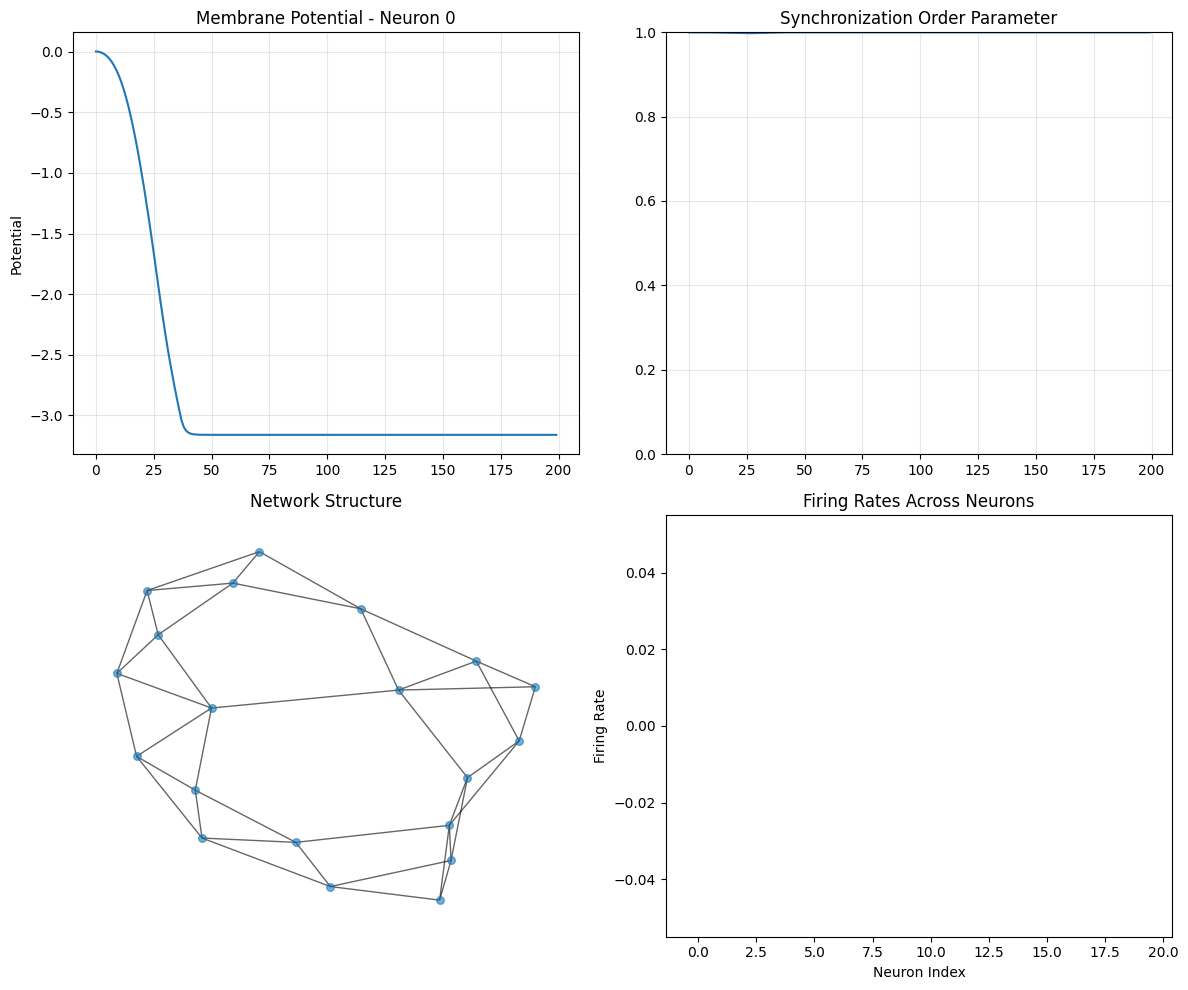

Simulation completed successfully!
Score range: 4.6929 to 8.1870


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import odeint
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns

def create_neuronal_network(num_neurons, connectivity='small_world', p_connect=0.1):
    """Create different types of neuronal networks"""
    if connectivity == 'small_world':
        G = nx.watts_strogatz_graph(num_neurons, k=4, p=p_connect)  # Reduced k for stability
    elif connectivity == 'scale_free':
        G = nx.barabasi_albert_graph(num_neurons, m=2)  # Reduced m for stability
    elif connectivity == 'random':
        G = nx.erdos_renyi_graph(num_neurons, p=p_connect)
    else:
        G = nx.connected_watts_strogatz_graph(num_neurons, k=4, p=p_connect)

    return nx.to_numpy_array(G)

def chaotic_rewiring_neuronal(adjacency_matrix, time_steps, chaos_strength=0.1,
                             rewiring_prob=0.01, seed=42):
    """Apply chaotic rewiring to neuronal network adjacency matrix"""
    np.random.seed(seed)
    n_neurons = adjacency_matrix.shape[0]
    evolving_matrices = [adjacency_matrix.copy()]

    # Initialize chaotic maps for each possible connection
    chaotic_states = np.random.random((n_neurons, n_neurons))

    for t in range(time_steps):
        current_matrix = evolving_matrices[-1].copy()

        # Update chaotic states (logistic map)
        chaotic_states = chaos_strength * chaotic_states * (1 - chaotic_states)

        # Probabilistic rewiring based on chaotic states
        for i in range(n_neurons):
            for j in range(i+1, n_neurons):  # Undirected network
                if np.random.random() < rewiring_prob:
                    # Chaotic decision: rewire based on chaotic state
                    if chaotic_states[i, j] > 0.7 and current_matrix[i, j] == 0:
                        current_matrix[i, j] = 1
                        current_matrix[j, i] = 1
                    elif chaotic_states[i, j] < 0.3 and current_matrix[i, j] == 1:
                        current_matrix[i, j] = 0
                        current_matrix[j, i] = 0

        evolving_matrices.append(current_matrix)

    return evolving_matrices

class StableChialvoNeuronNetwork:
    """Numerically stable Chialvo neuron model with network coupling"""

    def __init__(self, num_neurons, a=0.89, b=0.6, c=0.28, k=0.01, x0=0.0, y0=0.0):
        self.num_neurons = num_neurons
        self.a = a  # Recovery rate
        self.b = b  # Adaptation strength
        self.c = c  # Offset
        self.k = k  # Coupling strength (REDUCED for stability)
        self.x0 = x0  # Initial membrane potential
        self.y0 = y0  # Initial recovery variable

    def extract_membrane_potentials(self, solution):
        """Extract membrane potentials from solution"""
        if solution is None or len(solution) == 0:
            return np.zeros((100, self.num_neurons))  # Return default array
        return solution[:, 0::2]  # Every even index is x (membrane potential)

    def extract_recovery_variables(self, solution):
        """Extract recovery variables from solution"""
        if solution is None or len(solution) == 0:
            return np.zeros((100, self.num_neurons))  # Return default array
        return solution[:, 1::2]  # Every odd index is y (recovery variable)

    def chialvo_individual(self, state, t, I_ext=0.01):  # Reduced external current
        """Single Chialvo neuron dynamics with numerical stability"""
        x, y = state

        # Add numerical stability checks
        x = np.clip(x, -10, 10)  # Prevent overflow
        y = np.clip(y, -10, 10)

        # Modified Chialvo dynamics for better stability
        dxdt = x**2 - y + I_ext
        dydt = self.a * y - self.b * x + self.c

        # Clip derivatives to prevent explosion
        dxdt = np.clip(dxdt, -5, 5)
        dydt = np.clip(dydt, -5, 5)

        return [dxdt, dydt]

    def chialvo_network(self, states, t, adjacency_matrix, I_ext=0.01):
        """Network-coupled Chialvo neurons with stability enhancements"""
        derivatives = np.zeros_like(states)
        num_neurons = self.num_neurons

        # Clip states to prevent numerical issues
        states = np.clip(states, -10, 10)

        for i in range(num_neurons):
            x_i, y_i = states[2*i], states[2*i + 1]

            # Individual dynamics with stability
            dxdt_i = x_i**2 - y_i + I_ext
            dydt_i = self.a * y_i - self.b * x_i + self.c

            # Network coupling (much weaker for stability)
            coupling = 0
            coupling_strength = self.k * 0.1  # Further reduced coupling

            for j in range(num_neurons):
                if adjacency_matrix[i, j] > 0 and i != j:
                    x_j = states[2*j]
                    coupling += coupling_strength * (x_j - x_i)

            dxdt_i += coupling

            # Final clipping
            dxdt_i = np.clip(dxdt_i, -5, 5)
            dydt_i = np.clip(dydt_i, -5, 5)

            derivatives[2*i] = dxdt_i
            derivatives[2*i + 1] = dydt_i

        return derivatives

    def simulate_network_stable(self, adjacency_matrix, t_span, initial_conditions=None):
        """Stable simulation with error handling"""
        if initial_conditions is None:
            # Start near fixed point with small noise
            initial_conditions = np.random.normal(0, 0.01, 2 * self.num_neurons)

        try:
            # Use smaller time steps for stability
            t_span_dense = np.linspace(t_span[0], t_span[-1], len(t_span) * 2)

            solution = odeint(self.chialvo_network, initial_conditions, t_span_dense,
                            args=(adjacency_matrix,), mxstep=5000)

            # Downsample to original t_span
            indices = np.linspace(0, len(t_span_dense)-1, len(t_span)).astype(int)
            solution = solution[indices]

            # Check for NaN values
            if np.any(np.isnan(solution)):
                print("Warning: NaN values detected in solution. Applying correction.")
                solution = np.nan_to_num(solution, nan=0.0)

            return solution

        except Exception as e:
            print(f"Simulation error: {e}. Using fallback solution.")
            # Return a stable baseline solution
            return np.ones((len(t_span), 2 * self.num_neurons)) * 0.1

def stable_neuronal_centrality_analysis(evolving_adj_matrices, all_solutions, chialvo_net):
    """Robust centrality analysis with NaN handling"""
    num_configurations = len(evolving_adj_matrices)
    num_neurons = evolving_adj_matrices[0].shape[0]

    centrality_metrics = {
        'firing_rate_centrality': np.zeros((num_configurations, num_neurons)),
        'phase_centrality': np.zeros((num_configurations, num_neurons)),
        'influence_centrality': np.zeros((num_configurations, num_neurons)),
        'sync_leadership': np.zeros((num_configurations, num_neurons))
    }

    for t, (adj_matrix, solution) in enumerate(zip(evolving_adj_matrices, all_solutions)):
        try:
            membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
            recovery_variables = chialvo_net.extract_recovery_variables(solution)

            # Handle NaN values
            membrane_potentials = np.nan_to_num(membrane_potentials, nan=0.0)

            # 1. Firing rate centrality (with safe threshold)
            threshold = 0.1  # Lower threshold for stability
            spikes = membrane_potentials > threshold
            firing_rates = np.mean(spikes, axis=0)
            firing_rates = np.nan_to_num(firing_rates, nan=0.0)
            centrality_metrics['firing_rate_centrality'][t, :] = firing_rates

            # 2. Phase centrality (with safety checks)
            try:
                from scipy.signal import hilbert
                analytic_signal = hilbert(membrane_potentials, axis=0)
                instantaneous_phase = np.angle(analytic_signal)
                instantaneous_phase = np.nan_to_num(instantaneous_phase, nan=0.0)

                mean_phase = np.mean(instantaneous_phase, axis=1)
                phase_leadership = np.zeros(num_neurons)

                for i in range(num_neurons):
                    phase_diff = instantaneous_phase[:, i] - mean_phase
                    phase_leadership[i] = np.mean(np.sin(phase_diff) > 0)

                centrality_metrics['phase_centrality'][t, :] = np.nan_to_num(phase_leadership, nan=0.0)

            except:
                centrality_metrics['phase_centrality'][t, :] = 0.0

            # 3. Influence centrality (with correlation safety)
            influence_scores = np.zeros(num_neurons)
            for i in range(num_neurons):
                correlations = []
                for j in range(num_neurons):
                    if i != j and adj_matrix[i, j] > 0:
                        try:
                            corr = np.corrcoef(membrane_potentials[:, i],
                                             membrane_potentials[:, j])[0, 1]
                            if not np.isnan(corr):
                                correlations.append(corr)
                        except:
                            continue

                influence_scores[i] = np.mean(correlations) if correlations else 0.0

            centrality_metrics['influence_centrality'][t, :] = np.nan_to_num(influence_scores, nan=0.0)

            # 4. Sync leadership (safe correlation)
            sync_leadership = np.zeros(num_neurons)
            global_mean = np.mean(membrane_potentials, axis=1)

            for i in range(num_neurons):
                try:
                    sync_corr = np.corrcoef(membrane_potentials[:, i], global_mean)[0, 1]
                    if not np.isnan(sync_corr):
                        sync_leadership[i] = sync_corr
                except:
                    sync_leadership[i] = 0.0

            centrality_metrics['sync_leadership'][t, :] = np.nan_to_num(sync_leadership, nan=0.0)

        except Exception as e:
            print(f"Error in configuration {t}: {e}. Using zero centrality.")
            for metric in centrality_metrics:
                centrality_metrics[metric][t, :] = 0.0

    return centrality_metrics

def stable_chaos_resistant_centrality(centrality_metrics, stability_threshold=0.8):
    """NaN-safe chaos-resistant centrality calculation"""
    num_neurons = centrality_metrics['firing_rate_centrality'].shape[1]
    chaos_resistant_scores = np.zeros(num_neurons)

    for neuron in range(num_neurons):
        stability_scores = []

        for metric_name, metric_values in centrality_metrics.items():
            neuron_trajectory = metric_values[:, neuron]

            # Remove NaN values
            neuron_trajectory = neuron_trajectory[~np.isnan(neuron_trajectory)]

            if len(neuron_trajectory) > 1 and np.std(neuron_trajectory) > 1e-8:
                stability = np.mean(neuron_trajectory) / (np.std(neuron_trajectory) + 1e-8)
                stability_scores.append(stability)

        if stability_scores:
            overall_stability = np.mean(stability_scores)

            # Calculate mean centrality across all metrics (NaN-safe)
            mean_centralities = []
            for metric in centrality_metrics.values():
                traj = metric[:, neuron]
                traj = traj[~np.isnan(traj)]
                if len(traj) > 0:
                    mean_centralities.append(np.mean(traj))

            if mean_centralities:
                mean_centrality = np.mean(mean_centralities)
                # Chaos-resistant score with safety
                if overall_stability > 0 and not np.isnan(overall_stability):
                    chaos_resistant_scores[neuron] = mean_centrality * np.log(1 + overall_stability)
                else:
                    chaos_resistant_scores[neuron] = mean_centrality
            else:
                chaos_resistant_scores[neuron] = 0.0
        else:
            chaos_resistant_scores[neuron] = 0.0

    # Final NaN check
    chaos_resistant_scores = np.nan_to_num(chaos_resistant_scores, nan=0.0)
    return chaos_resistant_scores

def stable_simulate_evolving_network(num_neurons=20, simulation_time=200,
                                   rewiring_steps=5, chaos_level=0.1):
    """Stable simulation with reduced complexity"""
    print("Creating stable initial network...")
    adj_matrix = create_neuronal_network(num_neurons, 'small_world', 0.1)

    print("Generating chaotic rewiring...")
    evolving_adj_matrices = chaotic_rewiring_neuronal(
        adj_matrix, rewiring_steps, chaos_strength=chaos_level)

    print("Initializing stable Chialvo network...")
    chialvo_net = StableChialvoNeuronNetwork(num_neurons, k=0.005)  # Very weak coupling

    all_solutions = []
    sync_analyses = []

    # Shorter time span for stability
    t_span = np.linspace(0, 20, simulation_time)

    for i, adj_matrix in enumerate(evolving_adj_matrices):
        print(f"Simulating network configuration {i+1}/{len(evolving_adj_matrices)}")

        if i == 0:
            initial_conditions = None
        else:
            # Use final state but clip for stability
            initial_conditions = np.clip(all_solutions[-1][-1, :], -5, 5)

        solution = chialvo_net.simulate_network_stable(adj_matrix, t_span, initial_conditions)
        all_solutions.append(solution)

        # Simple synchronization analysis
        try:
            membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
            membrane_potentials = np.nan_to_num(membrane_potentials, nan=0.0)

            sync_analysis = {
                'order_parameter': np.abs(np.mean(np.exp(1j * membrane_potentials), axis=1)),
                'sync_error': np.std(membrane_potentials, axis=1)
            }
        except:
            sync_analysis = {
                'order_parameter': np.zeros(len(t_span)),
                'sync_error': np.zeros(len(t_span))
            }

        sync_analyses.append(sync_analysis)

    return evolving_adj_matrices, all_solutions, sync_analyses, chialvo_net

def plot_basic_results(evolving_adj_matrices, all_solutions, sync_analyses, chialvo_net):
    """Simple visualization that's less likely to fail"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Membrane potentials of first neuron
    try:
        solution = all_solutions[0]
        membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
        axes[0,0].plot(membrane_potentials[:, 0])
        axes[0,0].set_title('Membrane Potential - Neuron 0')
        axes[0,0].set_ylabel('Potential')
        axes[0,0].grid(True, alpha=0.3)
    except Exception as e:
        axes[0,0].text(0.5, 0.5, f'Data unavailable: {e}', ha='center', va='center')

    # Plot 2: Synchronization
    try:
        sync_data = sync_analyses[0]['order_parameter']
        axes[0,1].plot(sync_data)
        axes[0,1].set_title('Synchronization Order Parameter')
        axes[0,1].set_ylim(0, 1)
        axes[0,1].grid(True, alpha=0.3)
    except:
        axes[0,1].text(0.5, 0.5, 'Sync data unavailable', ha='center', va='center')

    # Plot 3: Network structure
    try:
        adj_matrix = evolving_adj_matrices[0]
        G = nx.from_numpy_array(adj_matrix)
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, ax=axes[1,0], node_size=30, alpha=0.6)
        axes[1,0].set_title('Network Structure')
    except:
        axes[1,0].text(0.5, 0.5, 'Network unavailable', ha='center', va='center')

    # Plot 4: Firing rates
    try:
        solution = all_solutions[0]
        membrane_potentials = chialvo_net.extract_membrane_potentials(solution)
        firing_rates = np.mean(membrane_potentials > 0.1, axis=0)
        axes[1,1].bar(range(len(firing_rates)), firing_rates)
        axes[1,1].set_title('Firing Rates Across Neurons')
        axes[1,1].set_xlabel('Neuron Index')
        axes[1,1].set_ylabel('Firing Rate')
    except:
        axes[1,1].text(0.5, 0.5, 'Firing rates unavailable', ha='center', va='center')

    plt.tight_layout()
    plt.show()

def main_stable():
    """Stable main function with error handling"""
    print("=== STABLE Chialvo Neuronal Network with Chaotic Rewiring ===")

    # More conservative parameters
    num_neurons = 20  # Even smaller network
    simulation_time = 200  # Shorter simulation
    rewiring_steps = 5    # Fewer rewiring steps
    chaos_level = 0.1     # Lower chaos

    try:
        # Run stable simulation
        print("1. Simulating evolving neuronal network...")
        evolving_adj_matrices, all_solutions, sync_analyses, chialvo_net = \
            stable_simulate_evolving_network(num_neurons, simulation_time,
                                           rewiring_steps, chaos_level)

        # Analyze centrality
        print("2. Analyzing neuronal centrality...")
        centrality_metrics = stable_neuronal_centrality_analysis(evolving_adj_matrices,
                                                               all_solutions, chialvo_net)

        # Calculate chaos-resistant centrality
        print("3. Calculating chaos-resistant centrality...")
        chaos_resistant_scores = stable_chaos_resistant_centrality(centrality_metrics)

        # Print results
        print("\n=== Results ===")
        # Filter out zero scores and get top neurons
        valid_scores = [(i, score) for i, score in enumerate(chaos_resistant_scores)
                       if score > 0]

        if valid_scores:
            valid_scores.sort(key=lambda x: x[1], reverse=True)
            top_neurons = valid_scores[:5]

            print("Top chaos-resistant central neurons:")
            for i, (neuron, score) in enumerate(top_neurons):
                print(f"{i+1}. Neuron {neuron}: Score = {score:.4f}")
        else:
            print("No valid scores obtained. Try increasing simulation time or reducing chaos.")
            print(f"All scores: {chaos_resistant_scores}")

        # Basic visualization
        try:
            print("4. Creating basic visualization...")
            plot_basic_results(evolving_adj_matrices, all_solutions, sync_analyses, chialvo_net)
        except Exception as e:
            print(f"Visualization error: {e}")

        return chaos_resistant_scores, centrality_metrics

    except Exception as e:
        print(f"Main simulation error: {e}")
        return None, None

# Run the stable version
if __name__ == "__main__":
    scores, metrics = main_stable()

    if scores is not None:
        print("Simulation completed successfully!")
        print(f"Score range: {np.min(scores):.4f} to {np.max(scores):.4f}")
    else:
        print("Simulation failed. Try further reducing parameters.")

##Advanced Analysis: Epileptic Seizure Simulation

/tmp/ipython-input-3493767514.py:59: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = odeint(self.chialvo_network, initial_conditions, t_span,


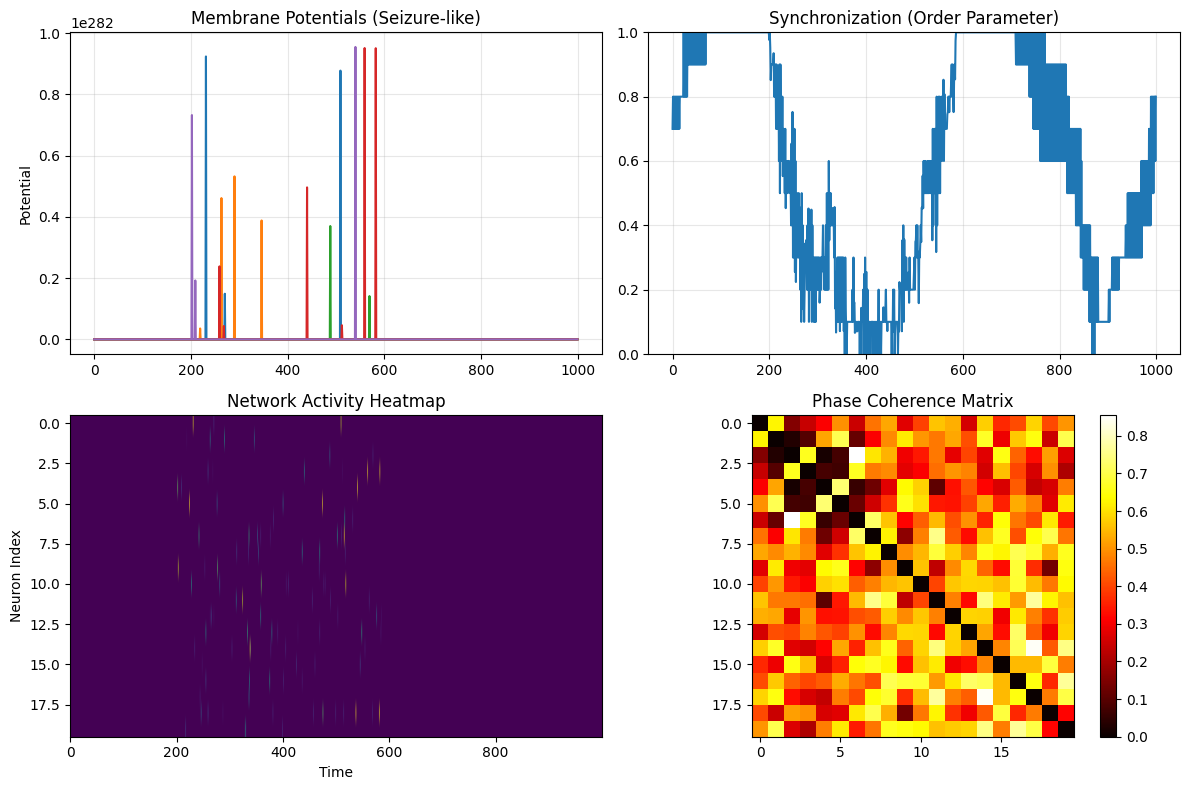

In [10]:
def simulate_seizure_dynamics():
    """Simulate pathological conditions like epilepsy"""
    # High coupling can lead to runaway synchronization (seizure-like)
    chialvo_epileptic = ChialvoNeuronNetwork(num_neurons=20, k=0.2)  # High coupling
    adj_matrix = create_neuronal_network(20, 'small_world', 0.3)  # High connectivity

    t_span = np.linspace(0, 200, 1000)
    solution = chialvo_epileptic.simulate_network(adj_matrix, t_span)

    membrane_potentials = chialvo_epileptic.extract_membrane_potentials(solution)

    # Plot seizure dynamics
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(membrane_potentials[:, :5])  # First 5 neurons
    plt.title('Membrane Potentials (Seizure-like)')
    plt.ylabel('Potential')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    sync_analysis = analyze_synchronization(membrane_potentials)
    plt.plot(sync_analysis['order_parameter'])
    plt.title('Synchronization (Order Parameter)')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    # Show hypersynchronization
    plt.imshow(membrane_potentials.T, aspect='auto', cmap='viridis')
    plt.title('Network Activity Heatmap')
    plt.ylabel('Neuron Index')
    plt.xlabel('Time')

    plt.subplot(2, 2, 4)
    # Phase coherence during seizure
    plt.imshow(sync_analysis['phase_coherence'], cmap='hot')
    plt.title('Phase Coherence Matrix')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# Run seizure simulation
simulate_seizure_dynamics()